# Klasifikasi DemogPairs Menggunakan Fitur ViT (Wajah, Emosi, dan Umur) & XGBoost

In [1]:
import numpy as np
import utils as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm

joblib.parallel_backend('threading')

C:\Users\Rezky\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
vggface_features = joblib.load('features/demogpairs_vit-face.pkl')
emotion_features = joblib.load('features/demogpairs_vit-emotion.pkl')
age_features = joblib.load('features/demogpairs_vit-age.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(vggface_features[key]) + list(emotion_features[key]) + list(age_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:04<00:00, 2436.61it/s]

Jumlah fitur per gambar: 2304


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
grid_params = [
    {
        'classifier': [XGBClassifier(n_jobs=1, random_state=42)],
        'classifier__tree_method': ['approx', 'hist'],
        'classifier__max_depth': [3, 6, 8],
        'classifier__gamma': [0.0, 0.1, 0.3],
        'classifier__min_child_weight': [1, 3, 5],
    }
]

pipeline = Pipeline(steps=[
    ('classifier', None)
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).replace('()', '')
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=1, num_parallel_tree=None, ...): 54 kombinasi


## Klasifikasi

Mengevaluasi model: XGBClassifier
Fitting 5 folds for each of 54 candidates, totalling 270 fits


{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}


Accuracy  : 0.8972222222222223
Precision : 0.897490481140855
Recall    : 0.8972222222222225
F1 Score  : 0.8971802285195823
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       360
           1       0.90      0.93      0.91       360
           2       0.85      0.86      0.86       360
           3       0.91      0.94      0.92       360
           4       0.92      0.88      0.90       360
           5       0.87      0.87      0.87       360

    accuracy                           0.90      2160
   macro avg       0.90      0.90      0.90      2160
weighted avg       0.90      0.90      0.90      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.975,0.9346590909090909,0.9138888888888889,0.9241573033707865
White_Females,0.9699074074074074,0.8975741239892183,0.925,0.9110807113543091
Asian_Males,0.9523148148148148,0.8539944903581267,0.8611111111111112,0.8575380359612724
White_Males,0.9740740740740741,0.9086021505376344,0.9388888888888889,0.9234972677595629
Black_Females,0.9666666666666667,0.9186046511627907,0.8777777777777778,0.8977272727272727
Asian_Females,0.9564814814814815,0.8715083798882681,0.8666666666666667,0.8690807799442897


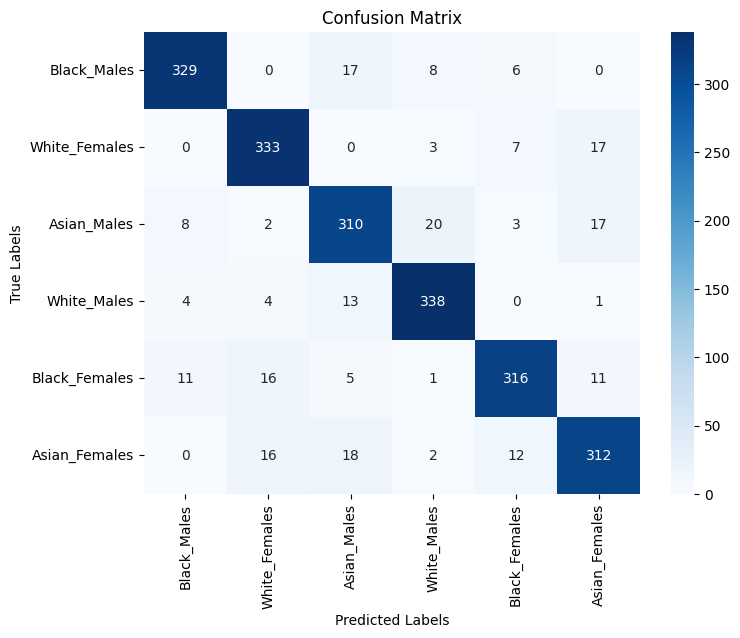

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
XGBClassifier,models/clf_demogpairs_xgb_vit-face-emotion-age_XGBClassifier.pkl,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.8972222222222223,0.8971802285195823,0.897490481140855,0.8972222222222225,54


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_xgb_vit-face-emotion-age_',
    results_path='results/demogpairs_xgb_vit-face-emotion-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_xgb_vit-face-emotion-age_XGBClassifier.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 84476.0,
 'days': 0,
 'hours': 23,
 'minutes': 27,
 'seconds': 56.0,
 'text': '0 hari 23 jam 27 menit 56.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 727359.0,
 'days': 8,
 'hours': 10,
 'minutes': 2,
 'seconds': 39.0,
 'text': '8 hari 10 jam 2 menit 39.0 detik'}

In [9]:
_dtable = u.display_table(fold_results, n_items=[4, 4], column_widths=['5%', '45%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Accuracy Mean,F1 Score Mean,Precision Mean,Recall Mean,Train Time Mean
1,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.1, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.9086,0.908,0.8958,0.9022,0.9028,0.9035,0.9034,0.9039,0.9035,4278.8379
2,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.9086,0.9091,0.8924,0.9016,0.9005,0.9024,0.9024,0.9028,0.9024,4300.1436
3,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 5, 'classifier__tree_method': 'approx'}",0.9097,0.8999,0.8924,0.9005,0.9086,0.9022,0.9022,0.9026,0.9022,4269.8132
4,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.0, 'classifier__max_depth': 3, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.9086,0.9062,0.8883,0.9045,0.9034,0.9022,0.9022,0.9027,0.9022,383.6906
...,...,...,...,...,...,...,...,...,...,...,...
51,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 6, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.8981,0.8854,0.8738,0.8854,0.8906,0.8867,0.8865,0.8871,0.8867,4555.6904
52,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__tree_method': 'approx'}",0.8924,0.8918,0.875,0.8837,0.8895,0.8865,0.8863,0.8868,0.8865,4660.9472
53,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'hist'}",0.8918,0.8825,0.8762,0.8866,0.886,0.8846,0.8844,0.885,0.8846,565.8346
54,"{'classifier': 'XGBClassifier', 'classifier__gamma': 0.3, 'classifier__max_depth': 8, 'classifier__min_child_weight': 1, 'classifier__tree_method': 'approx'}",0.8941,0.8814,0.8721,0.8837,0.8872,0.8837,0.8836,0.8843,0.8837,4718.3174
